In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"seveshss","key":"ec69b0f4cf9c9d0be901c2a330159f24"}'}

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Kaggle setup done ✅")

Kaggle setup done ✅


In [ ]:
!kaggle datasets download -d debeshjha1/kvasirseg
print("Download done ✅")

Dataset URL: https://www.kaggle.com/datasets/debeshjha1/kvasirseg
License(s): copyright-authors
100% 144M/144M [00:01<00:00, 122MB/s]

Download done ✅


In [ ]:
!unzip -q kvasirseg.zip -d kvasir-seg
print("Unzip done ✅")

Unzip done ✅


In [ ]:
import os

for root, dirs, files in os.walk('kvasir-seg'):
    level = root.replace('kvasir-seg', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for f in files[:3]:
            print(f'{indent}  {f}')

kvasir-seg/
  README.md
  train.txt
  val.txt
  Kvasir-SEG/
    Kvasir-SEG/
      bbox/
      annotated_images/
      masks/
      images/


In [ ]:
import os

imgs = os.listdir('kvasir-seg/Kvasir-SEG/Kvasir-SEG/images')
masks = os.listdir('kvasir-seg/Kvasir-SEG/Kvasir-SEG/masks')

print(f"Images: {len(imgs)}")
print(f"Masks: {len(masks)}")
print(f"Sample image: {imgs[0]}")
print(f"Sample mask: {masks[0]}")

Images: 1000
Masks: 1000
Sample image: cju6vrs1ov8cr098788h8gs6j.jpg
Sample mask: cju6vrs1ov8cr098788h8gs6j.jpg


In [ ]:
BASE_PATH = 'kvasir-seg/Kvasir-SEG/Kvasir-SEG'
IMG_PATH  = f'{BASE_PATH}/images'
MASK_PATH = f'{BASE_PATH}/masks'
TRAIN_TXT = 'kvasir-seg/train.txt'
VAL_TXT   = 'kvasir-seg/val.txt'

print('Base path set')
print(f'Images  -> {IMG_PATH}')
print(f'Masks   -> {MASK_PATH}')


Base path set ✅
Images  → kvasir-seg/Kvasir-SEG/Kvasir-SEG/images
Masks   → kvasir-seg/Kvasir-SEG/Kvasir-SEG/masks


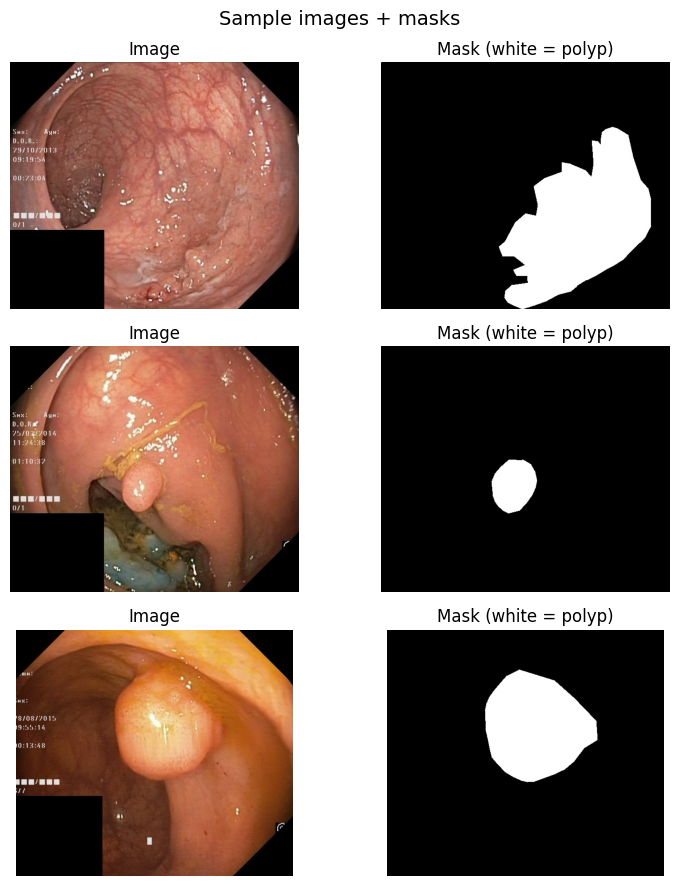

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random

def show_samples(img_path, mask_path, n=3):
    files = os.listdir(img_path)
    samples = random.sample(files, n)

    fig, axes = plt.subplots(n, 2, figsize=(8, n*3))
    fig.suptitle('Sample images + masks', fontsize=14)

    for i, fname in enumerate(samples):
        img  = cv2.imread(f'{img_path}/{fname}')
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(f'{mask_path}/{fname}', cv2.IMREAD_GRAYSCALE)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Image')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title('Mask (white = polyp)')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

show_samples(IMG_PATH, MASK_PATH)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

class KvasirDataset(Dataset):
    def __init__(self, txt_file, img_dir, mask_dir, img_size=256):
        with open(txt_file) as f:
            self.ids = [line.strip() for line in f.readlines()]
        self.img_dir  = img_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        fname = self.ids[idx] + '.jpg'
        img  = Image.open(f'{self.img_dir}/{fname}').convert('RGB')
        mask = Image.open(f'{self.mask_dir}/{fname}').convert('L')
        img  = self.transform(img)
        mask = self.transform(mask)
        mask = (mask > 0.5).float()
        return img, mask

# create datasets
train_dataset = KvasirDataset(TRAIN_TXT, IMG_PATH, MASK_PATH)
val_dataset   = KvasirDataset(VAL_TXT,   IMG_PATH, MASK_PATH)

# create loaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")

# quick sanity check
imgs, masks = next(iter(train_loader))
print(f"Image batch shape: {imgs.shape}")
print(f"Mask batch shape:  {masks.shape}")
print("Data loader ready ✅")

Train samples: 120
Val samples:   120
Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape:  torch.Size([8, 1, 256, 256])
Data loader ready ✅


In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(512, 1024)
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = UNet().to(device)

print(f"Model ready on: {device} ✅")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Model ready on: cuda ✅
Total parameters: 31,043,521


In [ ]:
from tqdm import tqdm

def dice_score(pred, target, threshold=0.5):
    pred   = (torch.sigmoid(pred) > threshold).float()
    inter  = (pred * target).sum()
    return (2 * inter) / (pred.sum() + target.sum() + 1e-8)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def train_one_epoch(loader):
    model.train()
    total_loss, total_dice = 0, 0
    for imgs, masks in tqdm(loader, desc='Training'):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_dice += dice_score(preds, masks).item()
    return total_loss/len(loader), total_dice/len(loader)

def val_one_epoch(loader):
    model.eval()
    total_loss, total_dice = 0, 0
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc='Validation'):
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            total_loss += criterion(preds, masks).item()
            total_dice += dice_score(preds, masks).item()
    return total_loss/len(loader), total_dice/len(loader)

# train for 20 epochs
EPOCHS = 20
best_dice = 0

for epoch in range(EPOCHS):
    train_loss, train_dice = train_one_epoch(train_loader)
    val_loss,   val_dice   = val_one_epoch(val_loader)

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Epoch {epoch+1:02d} | loss: {train_loss:.4f} | dice: {train_dice:.4f} | val_dice: {val_dice:.4f} ⭐ saved")
    else:
        print(f"Epoch {epoch+1:02d} | loss: {train_loss:.4f} | dice: {train_dice:.4f} | val_dice: {val_dice:.4f}")

print(f"\nBest val Dice: {best_dice:.4f} ✅")

Validation: 100%|██████████| 15/15 [00:04<00:00,  3.34it/s]


Epoch 01 | loss: 0.6102 | dice: 0.3357 | val_dice: 0.0347 ⭐ saved


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.28it/s]


Epoch 02 | loss: 0.5229 | dice: 0.3418 | val_dice: 0.0827 ⭐ saved


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.35it/s]


...

Validation: 100%|██████████| 15/15 [00:03<00:00,  4.10it/s]


Epoch 15 | loss: 0.3252 | dice: 0.6641 | val_dice: 0.6901 ⭐ saved


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.04it/s]


Epoch 16 | loss: 0.3055 | dice: 0.7010 | val_dice: 0.6819


Training:  40%|████      | 6/15 [00:03<00:05,  1.67it/s]

In [ ]:
# fix paths first
TRAIN_TXT = 'kvasir-seg/train.txt'
VAL_TXT   = 'kvasir-seg/val.txt'

# upgraded dataset with augmentations
from torchvision import transforms
import random

class KvasirDatasetV2(Dataset):
    def __init__(self, txt_file, img_dir, mask_dir, img_size=256, augment=False):
        with open(txt_file) as f:
            self.ids = [line.strip() for line in f.readlines()]
        self.img_dir  = img_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.augment  = augment
        self.resize   = transforms.Resize((img_size, img_size))
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        fname = self.ids[idx] + '.jpg'
        img  = Image.open(f'{self.img_dir}/{fname}').convert('RGB')
        mask = Image.open(f'{self.mask_dir}/{fname}').convert('L')

        img  = self.resize(img)
        mask = self.resize(mask)

        if self.augment:
            if random.random() > 0.5:
                img  = transforms.functional.hflip(img)
                mask = transforms.functional.hflip(mask)
            if random.random() > 0.5:
                img  = transforms.functional.vflip(img)
                mask = transforms.functional.vflip(mask)
            angle = random.choice([0, 90, 180, 270])
            img  = transforms.functional.rotate(img, angle)
            mask = transforms.functional.rotate(mask, angle)

        img  = self.to_tensor(img)
        mask = self.to_tensor(mask)
        mask = (mask > 0.5).float()
        return img, mask

# rebuild loaders with correct split
train_dataset = KvasirDatasetV2(TRAIN_TXT, IMG_PATH, MASK_PATH, augment=True)
val_dataset   = KvasirDatasetV2(VAL_TXT,   IMG_PATH, MASK_PATH, augment=False)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print("Upgraded data loader ready ✅")

In [ ]:
# fresh model
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# train for 30 epochs this time
EPOCHS = 30
best_dice = 0

for epoch in range(EPOCHS):
    train_loss, train_dice = train_one_epoch(train_loader)
    val_loss,   val_dice   = val_one_epoch(val_loader)

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Epoch {epoch+1:02d} | loss: {train_loss:.4f} | dice: {train_dice:.4f} | val_dice: {val_dice:.4f} ⭐ saved")
    else:
        print(f"Epoch {epoch+1:02d} | loss: {train_loss:.4f} | dice: {train_dice:.4f} | val_dice: {val_dice:.4f}")

print(f"\nBest val Dice: {best_dice:.4f} ✅")

In [ ]:
!pip install segmentation-models-pytorch -q

In [ ]:
import segmentation_models_pytorch as smp

# pretrained ResNet34 encoder
model = smp.Unet(
    encoder_name    = 'resnet34',
    encoder_weights = 'imagenet',
    in_channels     = 3,
    classes         = 1,
)
model = model.to(device)

# better loss function: BCE + Dice combined
loss_fn = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model ready on: {device} ✅")
print(f"Total parameters: {total_params:,}")

In [ ]:
def train_one_epoch_v2(loader):
    model.train()
    total_loss, total_dice = 0, 0
    for imgs, masks in tqdm(loader, desc='Training'):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = loss_fn(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_dice += dice_score(preds, masks).item()
    return total_loss/len(loader), total_dice/len(loader)

def val_one_epoch_v2(loader):
    model.eval()
    total_loss, total_dice = 0, 0
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc='Validation'):
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            total_loss += loss_fn(preds, masks).item()
            total_dice += dice_score(preds, masks).item()
    return total_loss/len(loader), total_dice/len(loader)

EPOCHS   = 30
best_dice = 0

for epoch in range(EPOCHS):
    train_loss, train_dice = train_one_epoch_v2(train_loader)
    val_loss,   val_dice   = val_one_epoch_v2(val_loader)

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), 'best_model_resnet.pth')
        print(f"Epoch {epoch+1:02d} | loss: {train_loss:.4f} | dice: {train_dice:.4f} | val_dice: {val_dice:.4f} ⭐ saved")
    else:
        print(f"Epoch {epoch+1:02d} | loss: {train_loss:.4f} | dice: {train_dice:.4f} | val_dice: {val_dice:.4f}")

print(f"\nBest val Dice: {best_dice:.4f} ✅")

In [ ]:
import matplotlib.pyplot as plt
import torch

def visualize_predictions(loader, model, device, n=4):
    model.eval()
    imgs, masks = next(iter(loader))
    imgs, masks = imgs.to(device), masks.to(device)

    with torch.no_grad():
        preds = torch.sigmoid(model(imgs))
        preds = (preds > 0.5).float()

    fig, axes = plt.subplots(n, 3, figsize=(12, n*4))
    fig.suptitle('Results: image | ground truth | prediction', fontsize=14)

    for i in range(n):
        img  = imgs[i].cpu().permute(1,2,0).numpy()
        mask = masks[i].cpu().squeeze().numpy()
        pred = preds[i].cpu().squeeze().numpy()

        axes[i,0].imshow(img)
        axes[i,0].set_title('Input image')
        axes[i,0].axis('off')

        axes[i,1].imshow(mask, cmap='gray')
        axes[i,1].set_title('Ground truth')
        axes[i,1].axis('off')

        axes[i,2].imshow(pred, cmap='gray')
        axes[i,2].set_title('Predicted mask')
        axes[i,2].axis('off')

    plt.tight_layout()
    plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved as predictions.png ✅")

visualize_predictions(val_loader, model, device)

In [ ]:
def iou_score(pred, target, threshold=0.5):
    pred   = (torch.sigmoid(pred) > threshold).float()
    inter  = (pred * target).sum()
    union  = pred.sum() + target.sum() - inter
    return inter / (union + 1e-8)

def evaluate_full(loader, model, device):
    model.eval()
    total_dice, total_iou = 0, 0
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc='Evaluating'):
            imgs, masks = imgs.to(device), masks.to(device)
            preds       = model(imgs)
            total_dice += dice_score(preds, masks).item()
            total_iou  += iou_score(preds, masks).item()
    return total_dice/len(loader), total_iou/len(loader)

print("Running full evaluation...\n")
dice, iou = evaluate_full(val_loader, model, device)

print("=" * 40)
print(f"  Model       : U-Net + ResNet34")
print(f"  Dataset     : Kvasir-SEG (1000 images)")
print(f"  Val samples : 120")
print(f"  Dice Score  : {dice:.4f}")
print(f"  IoU Score   : {iou:.4f}")
print("=" * 40)
print("\nThese are your application metrics ✅")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
save_dir = '/content/drive/MyDrive/kvasir-project'
os.makedirs(save_dir, exist_ok=True)

shutil.copy('best_model_resnet.pth', f'{save_dir}/best_model_resnet.pth')
shutil.copy('predictions.png',       f'{save_dir}/predictions.png')

print(f"Saved to Google Drive ✅")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install segmentation-models-pytorch -q

import torch
import segmentation_models_pytorch as smp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = smp.Unet(
    encoder_name    = 'resnet34',
    encoder_weights = None,
    in_channels     = 3,
    classes         = 1,
)
model.load_state_dict(torch.load('/content/drive/MyDrive/kvasir-project/best_model_resnet.pth', map_location=device))
model = model.to(device)
model.eval()
print(f'Model loaded from Drive on: {device} ✅')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.2 MB/s eta 0:00:00
Model loaded from Drive on: cuda ✅


In [4]:
!kaggle datasets download -d debeshjha1/kvasirseg -q
!unzip -q kvasirseg.zip -d kvasir-seg

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import random, os

BASE_PATH = 'kvasir-seg/Kvasir-SEG/Kvasir-SEG'
IMG_PATH  = f'{BASE_PATH}/images'
MASK_PATH = f'{BASE_PATH}/masks'
VAL_TXT   = 'kvasir-seg/val.txt'

class KvasirDatasetV2(Dataset):
    def __init__(self, txt_file, img_dir, mask_dir, img_size=256):
        with open(txt_file) as f:
            self.ids = [line.strip() for line in f.readlines()]
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.resize    = transforms.Resize((img_size, img_size))
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        fname = self.ids[idx] + '.jpg'
        img   = Image.open(f'{self.img_dir}/{fname}').convert('RGB')
        mask  = Image.open(f'{self.mask_dir}/{fname}').convert('L')
        img   = self.to_tensor(self.resize(img))
        mask  = self.to_tensor(self.resize(mask))
        mask  = (mask > 0.5).float()
        return img, mask

val_dataset = KvasirDatasetV2(VAL_TXT, IMG_PATH, MASK_PATH)
val_loader  = DataLoader(val_dataset, batch_size=8, shuffle=False)
print(f'Val samples: {len(val_dataset)} ✅')

Dataset URL: https://www.kaggle.com/datasets/debeshjha1/kvasirseg
License(s): copyright-authors
Val samples: 120 ✅


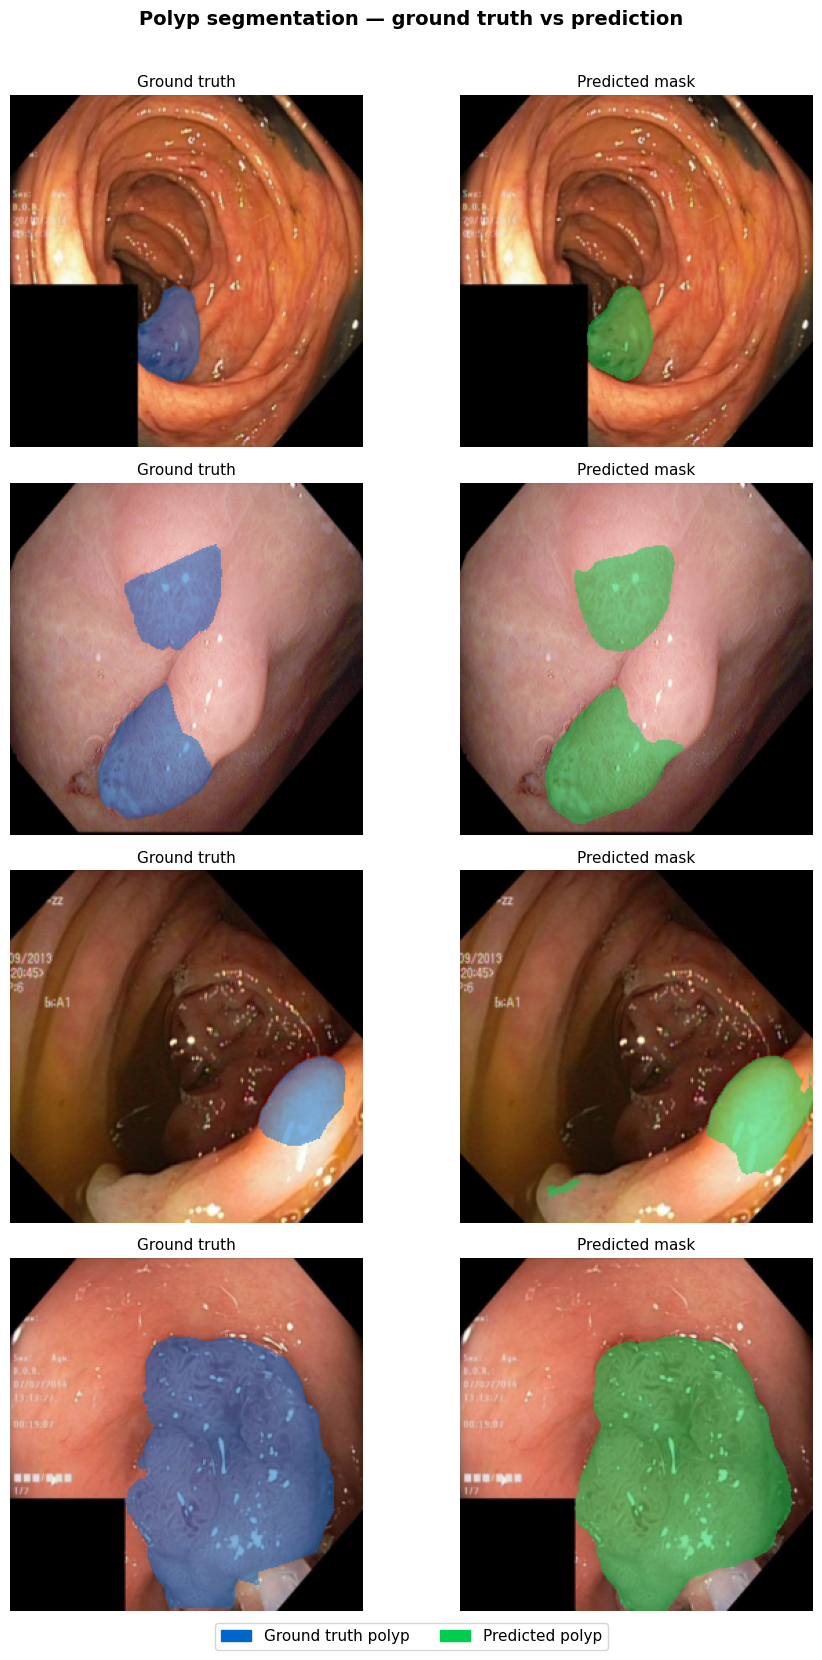

Saved as predictions_overlay.png ✅


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def visualize_overlay(loader, model, device, n=4):
    model.eval()
    imgs, masks = next(iter(loader))
    imgs, masks = imgs.to(device), masks.to(device)

    with torch.no_grad():
        preds = torch.sigmoid(model(imgs))
        preds = (preds > 0.5).float()

    fig, axes = plt.subplots(n, 2, figsize=(10, n*4))
    fig.suptitle('Polyp segmentation — ground truth vs prediction',
                 fontsize=14, fontweight='bold', y=1.01)

    for i in range(n):
        img  = imgs[i].cpu().permute(1,2,0).numpy()
        mask = masks[i].cpu().squeeze().numpy()
        pred = preds[i].cpu().squeeze().numpy()

        gt_overlay = img.copy()
        gt_overlay[mask == 1] = gt_overlay[mask == 1] * 0.5 + np.array([0, 0.4, 0.8]) * 0.5

        pred_overlay = img.copy()
        pred_overlay[pred == 1] = pred_overlay[pred == 1] * 0.5 + np.array([0, 0.8, 0.3]) * 0.5

        axes[i, 0].imshow(gt_overlay)
        axes[i, 0].set_title('Ground truth', fontsize=11)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(pred_overlay)
        axes[i, 1].set_title('Predicted mask', fontsize=11)
        axes[i, 1].axis('off')

    blue_patch  = mpatches.Patch(color=[0, 0.4, 0.8], label='Ground truth polyp')
    green_patch = mpatches.Patch(color=[0, 0.8, 0.3], label='Predicted polyp')
    fig.legend(handles=[blue_patch, green_patch],
               loc='lower center', ncol=2, fontsize=11,
               bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.savefig('predictions_overlay.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved as predictions_overlay.png ✅')

visualize_overlay(val_loader, model, device)

In [8]:
import shutil
shutil.copy('predictions_overlay.png', '/content/drive/MyDrive/kvasir-project/predictions_overlay.png')
print('Overlay saved to Drive ✅')

Overlay saved to Drive ✅


In [9]:
!pip install gradio -q
import gradio as gr
print("Gradio installed ✅")

Gradio installed ✅


In [10]:
from PIL import Image
import numpy as np
import torch
import gradio as gr

def predict(image):
    from torchvision import transforms

    # preprocess
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
    ])

    img_tensor = transform(image).unsqueeze(0).to(device)

    # predict
    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(img_tensor))
        pred = (pred > 0.5).float()

    # overlay
    img_np   = np.array(image.resize((256, 256))) / 255.0
    pred_np  = pred[0, 0].cpu().numpy()

    overlay  = img_np.copy()
    overlay[pred_np == 1] = overlay[pred_np == 1] * 0.5 + np.array([0, 0.8, 0.3]) * 0.5
    overlay  = (overlay * 255).astype(np.uint8)

    return Image.fromarray(overlay)

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Upload colonoscopy image"),
    outputs=gr.Image(type="pil", label="Predicted polyp region (green)"),
    title="Polyp Segmentation — U-Net + ResNet34",
    description="Upload a colonoscopy image to detect polyp regions automatically. Model trained on Kvasir-SEG dataset. Dice Score: 0.8602 | IoU: 0.7622",
    examples=None,
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9af0d4b4dcdc63f88b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [11]:
# get a sample image path to test with
import os
sample = os.listdir(IMG_PATH)[0]
print(f'{IMG_PATH}/{sample}')

kvasir-seg/Kvasir-SEG/Kvasir-SEG/images/cju6vrs1ov8cr098788h8gs6j.jpg


In [13]:
import shutil
shutil.copy('/content/drive/MyDrive/kvasir-project/best_model_resnet.pth', 'best_model_resnet.pth')

from google.colab import files
files.download('best_model_resnet.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>